C:\Users\kanis\AppData\Local\Temp\ipykernel_27428\579909857.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = df.groupby('Month')[['Domestic Price', 'Commercial Price']].mean().reset_index()


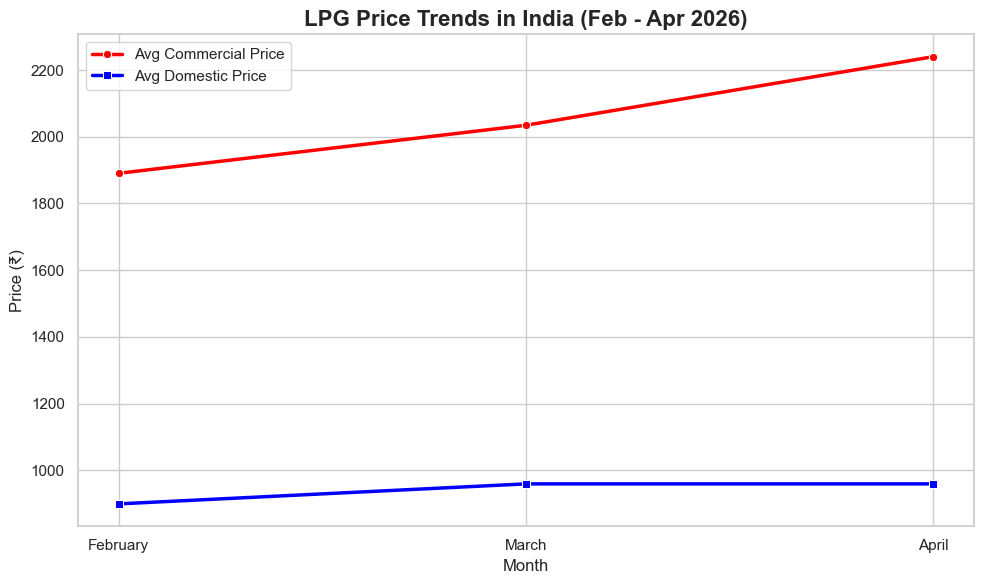

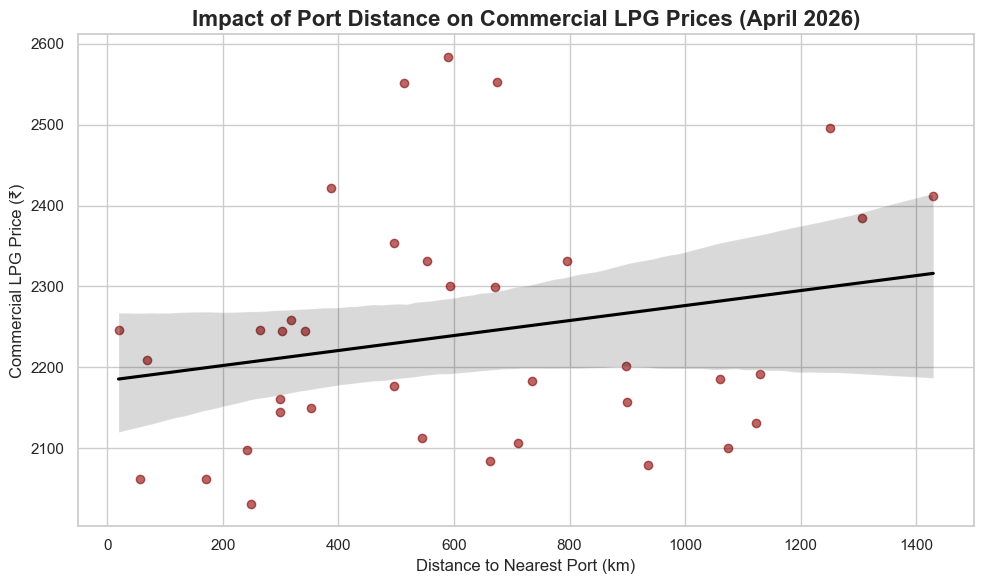

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the pristine master dataset
df = pd.read_csv("master_lpg_analysis_dataset_final.csv")

# 2. Tell Pandas the correct chronological order of the months
# Otherwise, it might plot April before February!
df['Month'] = pd.Categorical(df['Month'], categories=['February', 'March', 'April'], ordered=True)

# Set the visual style for professional-looking charts
sns.set_theme(style="whitegrid")

# CHART 1: The Timeline of the Crisis
plt.figure(figsize=(10, 6))

# Calculate the average price per month across all cities
monthly_avg = df.groupby('Month')[['Domestic Price', 'Commercial Price']].mean().reset_index()

# Plot both lines
sns.lineplot(data=monthly_avg, x='Month', y='Commercial Price', marker='o', label='Avg Commercial Price', color='red', linewidth=2.5)
sns.lineplot(data=monthly_avg, x='Month', y='Domestic Price', marker='s', label='Avg Domestic Price', color='blue', linewidth=2.5)

plt.title("LPG Price Trends in India (Feb - Apr 2026)", fontsize=16, fontweight='bold')
plt.ylabel("Price (₹)", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.legend()
plt.tight_layout()

# Save the plot as an image for your report
plt.savefig("price_trend_chart.png", dpi=300)
plt.show()

# CHART 2: The Geographic Supply Penalty in April
plt.figure(figsize=(10, 6))

# Filter data to ONLY look at April (the month of the crisis)
df_april = df[df['Month'] == 'April']

# Create a scatter plot with a trendline (regression line)
sns.regplot(data=df_april, x='Distance_to_Port_km', y='Commercial Price', 
            scatter_kws={'alpha':0.6, 'color':'darkred'}, line_kws={'color':'black'})

plt.title("Impact of Port Distance on Commercial LPG Prices (April 2026)", fontsize=16, fontweight='bold')
plt.ylabel("Commercial LPG Price (₹)", fontsize=12)
plt.xlabel("Distance to Nearest Port (km)", fontsize=12)
plt.tight_layout()

# Save the plot as an image for your report
plt.savefig("port_distance_scatter.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

city_coords_helper = {
    'Agartala': [23.8315, 91.2868], 'Ahmedabad': [23.0225, 72.5714], 'Aizawl': [23.7271, 92.7176],
    'Amritsar': [31.6340, 74.8723], 'Bengaluru': [12.9716, 77.5946], 'Bhopal': [23.2599, 77.4126],
    'Bhubaneswar': [20.2961, 85.8245], 'Chandigarh': [30.7333, 76.7794], 'Chennai': [13.0827, 80.2707],
    'Dehradun': [30.3165, 78.0322], 'Diu': [20.7144, 70.9822], 'Fatehabad': [29.5126, 75.4523],
    'Gangtok': [27.3314, 88.6138], 'Goa Panaji': [15.4909, 73.8278], 'Guntur Amaravathi': [16.5062, 80.5480],
    'Guwahati': [26.1445, 91.7362], 'Hyderabad': [17.3850, 78.4867], 'Imphal': [24.8170, 93.9368],
    'Itanagar': [27.0844, 93.6053], 'Jaipur': [26.9124, 75.7873], 'Kavaratti': [10.5667, 72.6417],
    'Kohima': [25.6751, 94.1086], 'Kolkata': [22.5726, 88.3639], 'Leh': [34.1526, 77.5771],
    'Lucknow': [26.8467, 80.9462], 'Mumbai': [19.0760, 72.8777], 'New Delhi': [28.6139, 77.2090],
    'Patna': [25.5941, 85.1376], 'Pondicherry': [11.9416, 79.8083], 'Port Blair': [11.6234, 92.7265],
    'Raipur': [21.2514, 81.6296], 'Ranchi': [23.3441, 85.3096], 'Shillong': [25.5788, 91.8933],
    'Shimla': [31.1048, 77.1734], 'Silvassa': [20.2763, 73.0022], 'Srinagar': [34.0837, 74.7973],
    'Thiruvananthapuram': [8.5241, 76.9366]
}

# 2. Load and Prep Pristine Master Data
df = pd.read_csv("master_lpg_analysis_dataset_final.csv")
df['Month'] = pd.Categorical(df['Month'], categories=['February', 'March', 'April'], ordered=True)
sns.set_theme(style="whitegrid") # For Seaborn plots

# Map coordinates to the main DataFrame
print("Mapping city coordinates...")
df['Latitude'] = df['City'].map(lambda x: city_coords_helper.get(x, [None, None])[0])
df['Longitude'] = df['City'].map(lambda x: city_coords_helper.get(x, [None, None])[1])

# Drop any cities we don't have coords for (for this illustration)
df_geo = df.dropna(subset=['Latitude', 'Longitude'])
print(f"Plotting geographical data for {df_geo['City'].nunique()} cities.")

# Interactive Geographic bubble Map (Plotly)
print("\nGenerating Interactive Geo Map (Plot 3)...")
df_april = df_geo[df_geo['Month'] == 'April']

# We are setting color by Price and Size by Port Distance. 
# Hovering gives all details, including the calculated port distance and global crude price.
fig = px.scatter_mapbox(df_april, 
                        lat="Latitude", lon="Longitude", 
                        size="Distance_to_Port_km", # Bubble size = Port distance penalty
                        color="Commercial Price",   # Bubble color = LPG price
                        color_continuous_scale=px.colors.sequential.YlOrRd, # High prices are DARK RED
                        size_max=30, zoom=3.5,
                        hover_name="City", 
                        hover_data=["Distance_to_Port_km", "Avg_Brent_Crude_USD"],
                        mapbox_style="carto-positron", # Clean, modern base map
                        title="April 2026: Commercial LPG Price and Port Distance Supply Chain Penalty")

# Make it look perfect
fig.update_layout(title_font_size=20, title_x=0.5, 
                  coloraxis_colorbar=dict(title="Commercial LPG (₹)"),
                  margin={"r":0,"t":50,"l":0,"b":0}) # Tight layout
fig.show(renderer="browser")

Mapping city coordinates...
Plotting geographical data for 37 cities.

Generating Interactive Geo Map (Plot 3)...


C:\Users\kanis\AppData\Local\Temp\ipykernel_27428\3687044067.py:49: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(df_april,


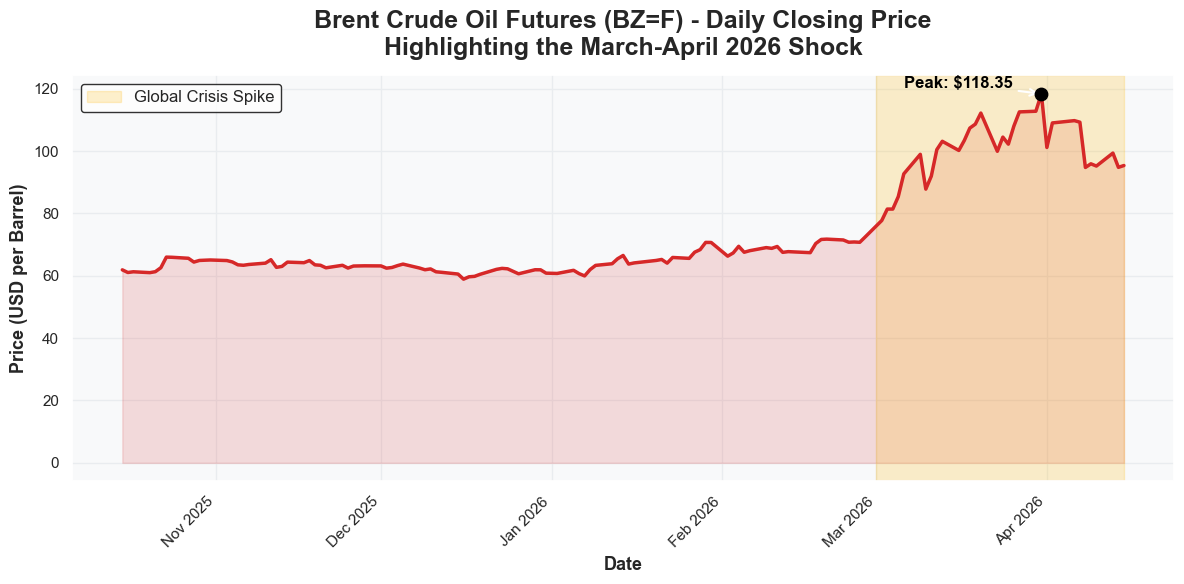

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Load the data directly from your CSV file
df = pd.read_csv("brent_crude_prices.csv")

# 2. Convert the 'Date' column to datetime format so Matplotlib understands the timeline
df['Date'] = pd.to_datetime(df['Date'])

# 3. Set up a premium visual theme (Light gray background with crisp gridlines)
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#f8f9fa", "grid.color": "#e9ecef"})
fig, ax = plt.subplots(figsize=(12, 6))

# 4. Plot the main red trendline
sns.lineplot(data=df, x='Date', y='BZ=F', color='#d62828', linewidth=2.5, ax=ax)

# Add a subtle red gradient fill under the line to give it weight
ax.fill_between(df['Date'], df['BZ=F'], alpha=0.15, color='#d62828')

# 5. Highlight the "Crisis Spike" (March 2026 to mid-April 2026) with a yellow shaded region
crisis_start = pd.to_datetime("2026-03-01")
crisis_end = pd.to_datetime("2026-04-15")
ax.axvspan(crisis_start, crisis_end, color='#ffb703', alpha=0.2, label="Global Crisis Spike")

# 6. Automatically find the absolute maximum price in your data and draw an arrow to it
peak_date = df.loc[df['BZ=F'].idxmax(), 'Date']
peak_value = df['BZ=F'].max()

ax.scatter(peak_date, peak_value, color='black', s=80, zorder=5) # Draw a black dot at the peak
ax.annotate(f'Peak: ${peak_value:.2f}', 
            xy=(peak_date, peak_value), 
            xytext=(peak_date - pd.Timedelta(days=25), peak_value + 2), # Position the text a bit to the left
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            fontsize=12, fontweight='bold', color='black')

# 7. Add bold, professional titles and axis labels
ax.set_title("Brent Crude Oil Futures (BZ=F) - Daily Closing Price\nHighlighting the March-April 2026 Shock", 
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=13, fontweight='bold')
ax.set_ylabel("Price (USD per Barrel)", fontsize=13, fontweight='bold')

# Format the dates on the x-axis to show "Month Year" (e.g., Oct 2025)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# 8. Add a legend and save the file in high resolution (300 dpi)
ax.legend(loc="upper left", fontsize=12, frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
plt.savefig("beautiful_brent_crude_plot.png", dpi=300)
plt.show()

C:\Users\kanis\AppData\Local\Temp\ipykernel_27428\3984319499.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_melt, x='Month', y='Consumption_KT', palette=custom_colors, ax=ax)


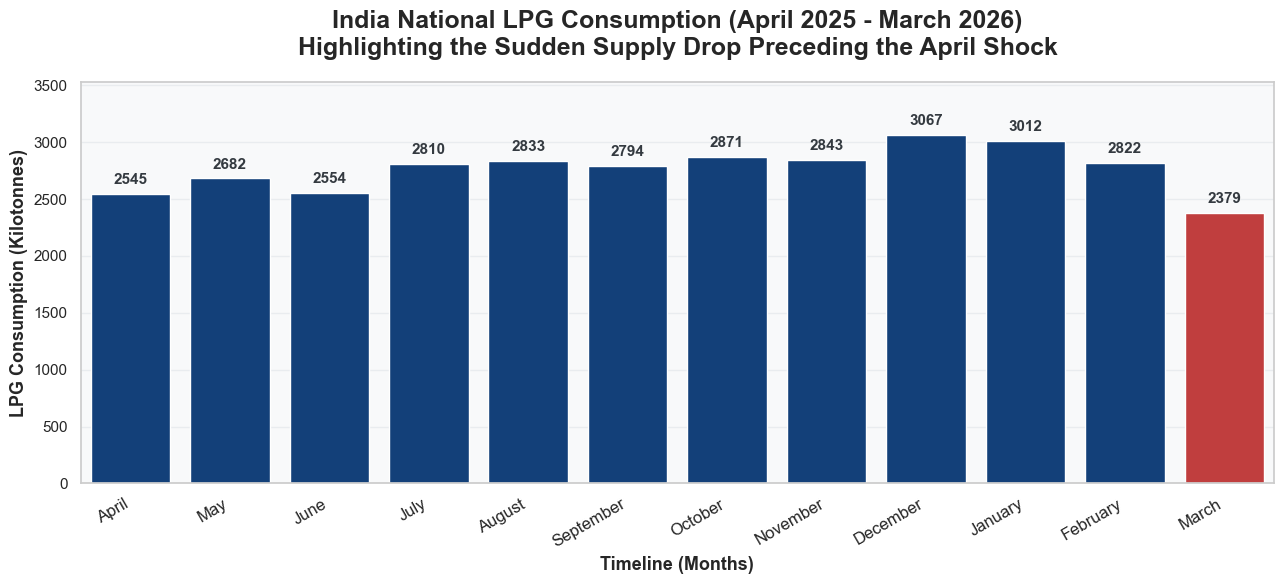

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_lpg = pd.read_csv("lpg_only_consumption.csv")
months_order = ['April', 'May', 'June', 'July', 'August', 'September', 
                'October', 'November', 'December', 'January', 'February', 'March']

# Melt the dataframe to get a 'Month' column and a 'Consumption' column
df_melt = df_lpg.melt(id_vars=["Products"], value_vars=months_order, 
                      var_name="Month", value_name="Consumption_KT")

# Tell Pandas the exact chronological order so it doesn't alphabetize the x-axis
df_melt['Month'] = pd.Categorical(df_melt['Month'], categories=months_order, ordered=True)

# 3. Set up the premium visual theme
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#f8f9fa", "grid.color": "#e9ecef"})
fig, ax = plt.subplots(figsize=(13, 6))

# 4. Create a custom color palette
# Normal months get a deep corporate blue. The crisis month (March) gets an alert red.
custom_colors = ['#023e8a' if month != 'March' else '#d62828' for month in df_melt['Month']]

# 5. Plot the bar chart
sns.barplot(data=df_melt, x='Month', y='Consumption_KT', palette=custom_colors, ax=ax)

# 6. Add exact numbers on top of each bar for maximum clarity
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#343a40', 
                xytext=(0, 5), textcoords='offset points')

# 7. Add bold, professional titles and axis labels
ax.set_title("India National LPG Consumption (April 2025 - March 2026)\nHighlighting the Sudden Supply Drop Preceding the April Shock", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Timeline (Months)", fontsize=13, fontweight='bold')
ax.set_ylabel("LPG Consumption (Kilotonnes)", fontsize=13, fontweight='bold')

# Give the chart a bit of headroom so the top numbers don't get cut off
ax.set_ylim(0, df_melt['Consumption_KT'].max() * 1.15) 

# Make the x-axis labels slightly angled so they are easy to read
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=11)

# 8. Save and show the plot
plt.tight_layout()
plt.savefig("beautiful_lpg_consumption_bar.png", dpi=300)
plt.show()